In [1]:
ENV["PYTHONPATH"] = "/home/gridsan/aligho/.local/lib/python3.8/site-packages/PyNormaliz-2.15-py3.8-linux-x86_64.egg";

In [3]:
using DelimitedFiles, PyPlot, LinearAlgebra
using Crystalline, Brillouin, MPBUtils, SymmetryBases
using Crystalline: TEST_αβγs, TEST_αβγ, dot, norm
topology_paper_dir = "../../TopologyPaper/"
include(topology_paper_dir * "get-freqs-symeigs.jl")
include(topology_paper_dir * "symeigs-from-io.jl");

In [4]:
io = open("dispersion.log")
logstr = read(io, String)
close(io)

In [5]:
dispersion_str = logs_to_dispersion(logstr, "");

In [6]:
dispersion = readdlm(IOBuffer(dispersion_str), ',')[:, 6:end]
kpts = readdlm(IOBuffer(dispersion_str), ',')[:, 2:4];

In [7]:
X_point_idxs = findall(x-> isapprox(x, 0), [norm([0.5, 0, 0] .- collect(row)) for row in eachrow(kpts)])
M_point_idxs = findall(x-> isapprox(x, 0), [norm([0.5, 0.5, 0] .- collect(row)) for row in eachrow(kpts)])
Gamma_point_idxs = findall(x-> isapprox(x, 0), [norm([0, 0, 0] .- collect(row)) for row in eachrow(kpts)])
R_point_idxs = findall(x-> isapprox(x, 0), [norm([0.5, 0.5, 0.5] .- collect(row)) for row in eachrow(kpts)]);

In [8]:
# Some more points in the Brillouin zone

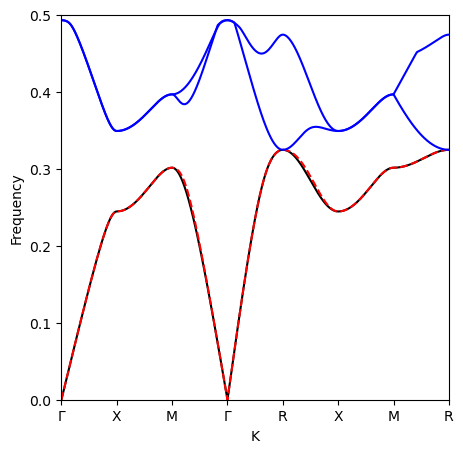

In [18]:
figure(figsize=(5, 5))
plot(1:first(size(dispersion)), dispersion[:, 1], color="black")
plot(1:first(size(dispersion)), dispersion[:, 2], color="red", linestyle="dashed")
plot(1:first(size(dispersion)), dispersion[:, 3], color="blue")
plot(1:first(size(dispersion)), dispersion[:, 4], color="blue")

xlim(1, first(size(dispersion)))
xticks([Gamma_point_idxs..., X_point_idxs..., R_point_idxs..., M_point_idxs...], [repeat(["Γ"], length(Gamma_point_idxs))...,
        repeat(["X"], length(X_point_idxs))..., repeat(["R"], length(R_point_idxs))...,  repeat(["M"], length(M_point_idxs))...])
ylim(0, 0.5)
ylabel("Frequency")
xlabel("K");